In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from os import fspath
%matplotlib inline
import seaborn as sns
import math
sns.set_context('talk')
import plotly.express as px
import pandas as pd
import MDAnalysis as mda
import nglview
mda.__version__

'0.20.1'

In [5]:
traj_dir = Path('../../data/post_processing_output/')
proc_dir = Path('../../data/aligned_traj')
GRO = traj_dir / 'md.gro'
XTC = traj_dir / 'md_noPBC.xtc'

In [9]:
rec_traj = mda.Universe(str(GRO), str(XTC))
rec_traj.trajectory.n_frames

4001

In [11]:
view = nglview.show_mdanalysis(rec_traj)
view

NGLWidget(count=4001)

In [12]:
from MDAnalysis.analysis.align import AlignTraj
from MDAnalysis.analysis.rms import RMSD, rmsd

In [13]:
rec_ref = mda.Universe(str(GRO), str(XTC))
frame_ref = rec_ref.trajectory[0]
sel = 'name CA'

In [19]:
R = RMSD(rec_traj, frame_ref, select = sel, groupselections=['backbone', 'resid 20:50 and name CA']).run()

AttributeError: 'Timestep' object has no attribute 'select_atoms'

In [17]:
rmsd_df1 = pd.DataFrame(R.rmsd, columns = ['idx', 'time', 'CA', 'backbone', 'resid_20:50'])

In [18]:
rmsd_df1

,idx,time,CA,backbone,resid_20:50
0,0.0,0.0,7.554226e-07,3.226643e-07,0.000000
1,1.0,50.0,8.838749e-01,9.015340e-01,1.058046
2,2.0,100.0,1.111546e+00,1.128830e+00,1.216064
3,3.0,150.0,1.192509e+00,1.202436e+00,1.243405
4,4.0,200.0,1.021659e+00,1.030387e+00,1.186609
...,...,...,...,...,...
3996,3996.0,199800.0,2.342312e+00,2.348862e+00,3.122441
3997,3997.0,199850.0,2.335793e+00,2.345628e+00,3.146070
3998,3998.0,199900.0,2.281480e+00,2.281236e+00,2.976224
3999,3999.0,199950.0,2.584172e+00,2.587039e+00,3.547847


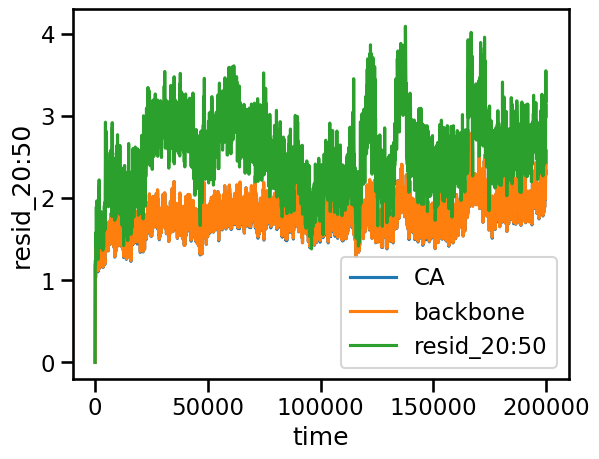

In [20]:
ax = sns.lineplot(data=rmsd_df1,x='time',y='CA', label='CA')
ax = sns.lineplot(data=rmsd_df1,x='time',y='backbone',ax=ax, label='backbone')
sns.lineplot(data=rmsd_df1,x='time',y='resid_20:50',ax=ax, label='resid_20:50')